In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
# ── Génération du dataset 
n = 80
marches = ['Mokolo','Sandaga','Marché Mvog-Mbi','New-Bell','Mfoundi']
produits = ['Riz (1kg)','Huile (1L)','Tomate (kg)','Plantain (kg)','Poulet (kg)',
'Igname (kg)','Arachide (kg)','Poisson fumé (kg)']
mois = ['Janvier 2024','Février 2024','Mars 2024']
# Prix de référence par produit (FCFA)
prix_ref = {
'Riz (1kg)':500,'Huile (1L)':1200,'Tomate (kg)':250,
'Plantain (kg)':300,'Poulet (kg)':2500,'Igname (kg)':400,
'Arachide (kg)':600,'Poisson fumé (kg)':3500
} 
data = []
for i in range(n):
    prod = np.random.choice(produits)
    marche = np.random.choice(marches)
    mois_v = np.random.choice(mois)
    prix_b = prix_ref[prod]
    # Prix avec variation réaliste (±20%)
    prix = max(50, int(prix_b * np.random.uniform(0.8, 1.2)))
    qty = np.random.randint(1, 50)
    data.append({'mois':mois_v,'marche':marche,'produit':prod,
'prix_fcfa':prix,'quantite':qty,'total':prix*qty})
df_raw = pd.DataFrame(data)
# ── Introduire des problèmes intentionnels ──────────────────────────
idx_nan = np.random.choice(df_raw.index, 8, replace=False)
idx_dup = np.random.choice(df_raw.index, 5, replace=False)
idx_out = np.random.choice(df_raw.index, 4, replace=False)
# Valeurs manquantes
df_raw.loc[idx_nan[:4], 'prix_fcfa'] = np.nan
df_raw.loc[idx_nan[4:], 'quantite'] = np.nan
# Doublons
df_raw = pd.concat([df_raw, df_raw.loc[idx_dup]], ignore_index=True)
# Outliers dans prix_fcfa
df_raw.loc[idx_out[:2], 'prix_fcfa'] = df_raw.loc[idx_out[:2],
'prix_fcfa'] * 10
df_raw.loc[idx_out[2:], 'quantite'] = 0
# Incohérences de casse dans marche
df_raw.loc[df_raw.index[:10], 'marche'] = df_raw.loc[df_raw.index[:10],
'marche'].str.upper()
print(f'Dataset brut : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes')
df_raw.head(10)

Dataset brut : 85 lignes, 6 colonnes


,mois,marche,produit,prix_fcfa,quantite,total
0,Janvier 2024,NEW-BELL,Arachide (kg),524.0,8.0,4192
1,Mars 2024,MFOUNDI,Poulet (kg),2445.0,23.0,56235
2,Janvier 2024,MARCHÉ MVOG-MBI,Tomate (kg),260.0,24.0,6240
3,Février 2024,MFOUNDI,Tomate (kg),272.0,30.0,8160
4,Janvier 2024,SANDAGA,Igname (kg),418.0,22.0,9196
5,Janvier 2024,NEW-BELL,Poulet (kg),2291.0,42.0,96222
6,Mars 2024,NEW-BELL,Poisson fumé (kg),3438.0,47.0,161586
7,Mars 2024,MARCHÉ MVOG-MBI,Igname (kg),477.0,NaN,1431
8,Mars 2024,MARCHÉ MVOG-MBI,Poulet (kg),2170.0,39.0,84630
9,Janvier 2024,NEW-BELL,Huile (1L),1423.0,9.0,12807


In [3]:
df_raw.shape

(85, 6)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mois       85 non-null     object 
 1   marche     85 non-null     object 
 2   produit    85 non-null     object 
 3   prix_fcfa  81 non-null     float64
 4   quantite   81 non-null     float64
 5   total      85 non-null     int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.1+ KB


In [5]:
df_raw.isnull().sum()

mois         0
marche       0
produit      0
prix_fcfa    4
quantite     4
total        0
dtype: int64

In [9]:
df_raw.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
80     True
81     True
82     True
83     True
84     True
Length: 85, dtype: bool

In [13]:
print(df_raw.duplicated().sum())

5


In [14]:
df_raw[df_raw.duplicated(keep=False)]

,mois,marche,produit,prix_fcfa,quantite,total
13,Février 2024,Sandaga,Igname (kg),325.0,18.0,5850
27,Janvier 2024,New-Bell,Huile (1L),1056.0,32.0,33792
36,Février 2024,Marché Mvog-Mbi,Poisson fumé (kg),3106.0,24.0,74544
56,Février 2024,Sandaga,Huile (1L),1175.0,41.0,48175
57,Janvier 2024,Mokolo,Plantain (kg),299.0,48.0,14352
80,Janvier 2024,New-Bell,Huile (1L),1056.0,32.0,33792
81,Février 2024,Sandaga,Igname (kg),325.0,18.0,5850
82,Janvier 2024,Mokolo,Plantain (kg),299.0,48.0,14352
83,Février 2024,Marché Mvog-Mbi,Poisson fumé (kg),3106.0,24.0,74544
84,Février 2024,Sandaga,Huile (1L),1175.0,41.0,48175


In [15]:
df_raw.describe()

,prix_fcfa,quantite,total
count,81.000000,81.000000,85.000000
mean,1245.086420,24.938272,29279.364706
std,1288.815388,14.390401,35707.505157
min,228.000000,0.000000,632.000000
25%,368.000000,14.000000,6993.000000
50%,564.000000,24.000000,12672.000000
75%,1399.000000,35.000000,33792.000000
max,6740.000000,49.000000,161586.000000


In [16]:
print(f"Quantités égales à 0 : {(df_raw['quantite'] == 0).sum()}")

Quantités égales à 0 : 2


In [17]:
print(f"Casse incohérente (Majuscules) : {df_raw['marche'].str.isupper().sum()}")

Casse incohérente (Majuscules) : 10


In [18]:
df = df_raw.copy()

print(f"Avant nettoyage : {df.shape[0]} lignes")
print("Valeurs manquantes initiales :")
print(df.isnull().sum())

Avant nettoyage : 85 lignes
Valeurs manquantes initiales :
mois         0
marche       0
produit      0
prix_fcfa    4
quantite     4
total        0
dtype: int64


In [19]:
df['marche'] = df['marche'].str.title()

print("Répartition des marchés après standardisation :")
print(df['marche'].value_counts())

# Vérification de l'état du dataset
print(f"\nDimensions : {df.shape}")

Répartition des marchés après standardisation :
marche
New-Bell           24
Mfoundi            17
Mokolo             16
Marché Mvog-Mbi    15
Sandaga            13
Name: count, dtype: int64

Dimensions : (85, 6)


In [20]:
df = df.drop_duplicates()

print(f"Après suppression des doublons : {df.shape[0]} lignes")

Après suppression des doublons : 80 lignes


In [21]:
mediane_prix = df.groupby('produit')['prix_fcfa'].transform('median')
df['prix_fcfa'] = df['prix_fcfa'].fillna(mediane_prix)

mediane_qty = df.groupby('produit')['quantite'].transform('median')
df['quantite'] = df['quantite'].fillna(mediane_qty)

print(f'Dimensions après imputation : {df.shape}')
print('NaN restants par colonne :')
print(df.isnull().sum())
print(f'\nTotal NaN restants : {df.isnull().sum().sum()}')

Dimensions après imputation : (80, 6)
NaN restants par colonne :
mois         0
marche       0
produit      0
prix_fcfa    0
quantite     0
total        0
dtype: int64

Total NaN restants : 0


In [22]:
# Fonction générique de détection/correction IQR
def corriger_outliers_iqr(serie, nom_col=''):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    
    n_out = ((serie < borne_inf) | (serie > borne_sup)).sum()
    print(f'{nom_col}: {n_out} outliers détectés → Bornes : [{borne_inf:.0f}, {borne_sup:.0f}]')
    
    # Plafonnement des valeurs (clip)
    return serie.clip(lower=borne_inf, upper=borne_sup)

# Appliquer sur les deux colonnes numériques
df['prix_fcfa'] = corriger_outliers_iqr(df['prix_fcfa'], 'prix_fcfa')
df['quantite'] = corriger_outliers_iqr(df['quantite'], 'quantite')

# Recalculer le total après corrections (essentiel car les prix/quantités ont changé)
df['total'] = df['prix_fcfa'] * df['quantite']

print(f'\nAprès nettoyage complet : {df.shape[0]} lignes, {df.isnull().sum().sum()} NaN')


prix_fcfa: 14 outliers détectés → Bornes : [-1107, 2912]
quantite: 0 outliers détectés → Bornes : [-18, 64]

Après nettoyage complet : 80 lignes, 0 NaN


In [23]:
# 1. Implémentation de la fonction de catégorisation
def categoriser_prix(row):
    """
    Compare le prix de la ligne à la médiane du produit.
    Retourne 'Cher' si > 10% au-dessus, 'Normal' sinon.
    """
    mediane = df[df['produit'] == row['produit']]['prix_fcfa'].median()
    if row['prix_fcfa'] > mediane * 1.1:
        return 'Cher'
    elif row['prix_fcfa'] < mediane * 0.9:
        return 'Bonne affaire'
    else:
        return 'Prix normal'

# Application de la fonction (ligne par ligne)
df['statut_prix'] = df.apply(categoriser_prix, axis=1)

# 2. Médiane pour calcul d'écart
mediane_ref = df.groupby('produit')['prix_fcfa'].transform('median')

# Calcul de l'écart en pourcentage
df['ecart_median_pct'] = (df['prix_fcfa'] - mediane_ref) / mediane_ref * 100

# 3. Création des tranches de prix fixes
df['tranche_prix'] = pd.cut(
    df['prix_fcfa'], 
    bins=[0, 300, 600, 1500, float('inf')], 
    labels=['Bas', 'Moyen', 'Élevé', 'Premium']
)

# Affichage des résultats
print("Aperçu des nouvelles colonnes calculées :")
cols_view = ['produit', 'prix_fcfa', 'ecart_median_pct', 'tranche_prix', 'statut_prix']
print(df[cols_view].head(10))


Aperçu des nouvelles colonnes calculées :
             produit  prix_fcfa  ecart_median_pct tranche_prix    statut_prix
0      Arachide (kg)    524.000        -15.072934        Moyen  Bonne affaire
1        Poulet (kg)   2445.000         -5.961538      Premium    Prix normal
2        Tomate (kg)    260.000         -2.255639          Bas    Prix normal
3        Tomate (kg)    272.000          2.255639          Bas    Prix normal
4        Igname (kg)    418.000         -0.947867        Moyen    Prix normal
5        Poulet (kg)   2291.000        -11.884615      Premium  Bonne affaire
6  Poisson fumé (kg)   2912.125          0.000000      Premium    Prix normal
7        Igname (kg)    477.000         13.033175        Moyen           Cher
8        Poulet (kg)   2170.000        -16.538462      Premium  Bonne affaire
9         Huile (1L)   1423.000         25.264085        Élevé           Cher


In [24]:
classement_prix = df.groupby('produit')['prix_fcfa'].mean().sort_values(ascending=False)
print("Prix moyen par produit (FCFA) :")
print(classement_prix)

Prix moyen par produit (FCFA) :
produit
Poisson fumé (kg)    2912.125000
Poulet (kg)          2583.607143
Huile (1L)           1159.187500
Arachide (kg)         884.140625
Plantain (kg)         585.712500
Riz (1kg)             490.444444
Igname (kg)           416.166667
Tomate (kg)           262.375000
Name: prix_fcfa, dtype: float64


Chiffre d'affaires par marché :
marche
New-Bell           793081.125
Mfoundi            504777.875
Marché Mvog-Mbi    403057.250
Mokolo             305589.250
Sandaga            195662.000
Name: total, dtype: float64


<Axes: title={'center': 'CA par Marché'}, xlabel='marche'>

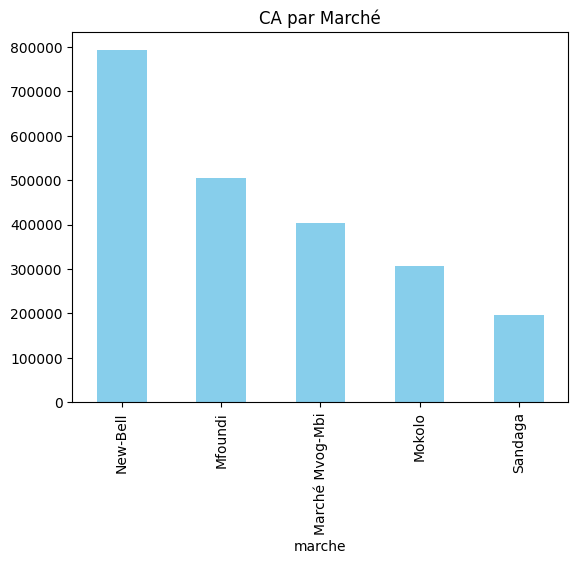

In [25]:
ca_marches = df.groupby('marche')['total'].sum().sort_values(ascending=False)
print("Chiffre d'affaires par marché :")
print(ca_marches)

# Visualisation rapide
ca_marches.plot(kind='bar', color='skyblue', title='CA par Marché')

In [26]:
pivot_prix = df.pivot_table(index='produit', columns='marche', values='prix_fcfa', aggfunc='mean')
variation = pivot_prix.max(axis=1) - pivot_prix.min(axis=1)
print("Variation max-min par produit :")
print(variation.sort_values(ascending=False))

Variation max-min par produit :
produit
Plantain (kg)        1319.895833
Arachide (kg)        1207.729167
Poulet (kg)           527.125000
Huile (1L)            176.600000
Igname (kg)            75.500000
Riz (1kg)              62.500000
Tomate (kg)            57.500000
Poisson fumé (kg)       0.000000
dtype: float64


Prix moyen mensuel :
mois
Janvier 2024     754.713235
Février 2024    1398.513158
Mars 2024       1405.879630
Name: prix_fcfa, dtype: float64


<Axes: title={'center': 'Évolution du prix moyen'}, xlabel='mois'>

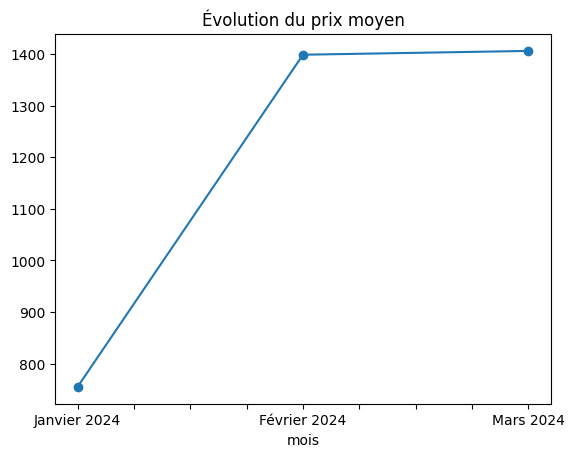

In [27]:
ordre_mois = ['Janvier 2024', 'Février 2024', 'Mars 2024']
evolution_prix = df.groupby('mois')['prix_fcfa'].mean().reindex(ordre_mois)

print("Prix moyen mensuel :")
print(evolution_prix)

evolution_prix.plot(kind='line', marker='o', title='Évolution du prix moyen')

In [28]:
top_ecarts = df.sort_values(by='ecart_median_pct', ascending=False).head(3)
print("Top 3 des prix les plus 'chers' par rapport à la normale :")
print(top_ecarts[['marche', 'produit', 'prix_fcfa', 'ecart_median_pct']])

Top 3 des prix les plus 'chers' par rapport à la normale :
             marche        produit  prix_fcfa  ecart_median_pct
59  Marché Mvog-Mbi  Plantain (kg)   2912.125        759.033923
72          Mfoundi  Arachide (kg)   2912.125        371.981361
66          Mfoundi      Riz (1kg)    592.000         33.033708


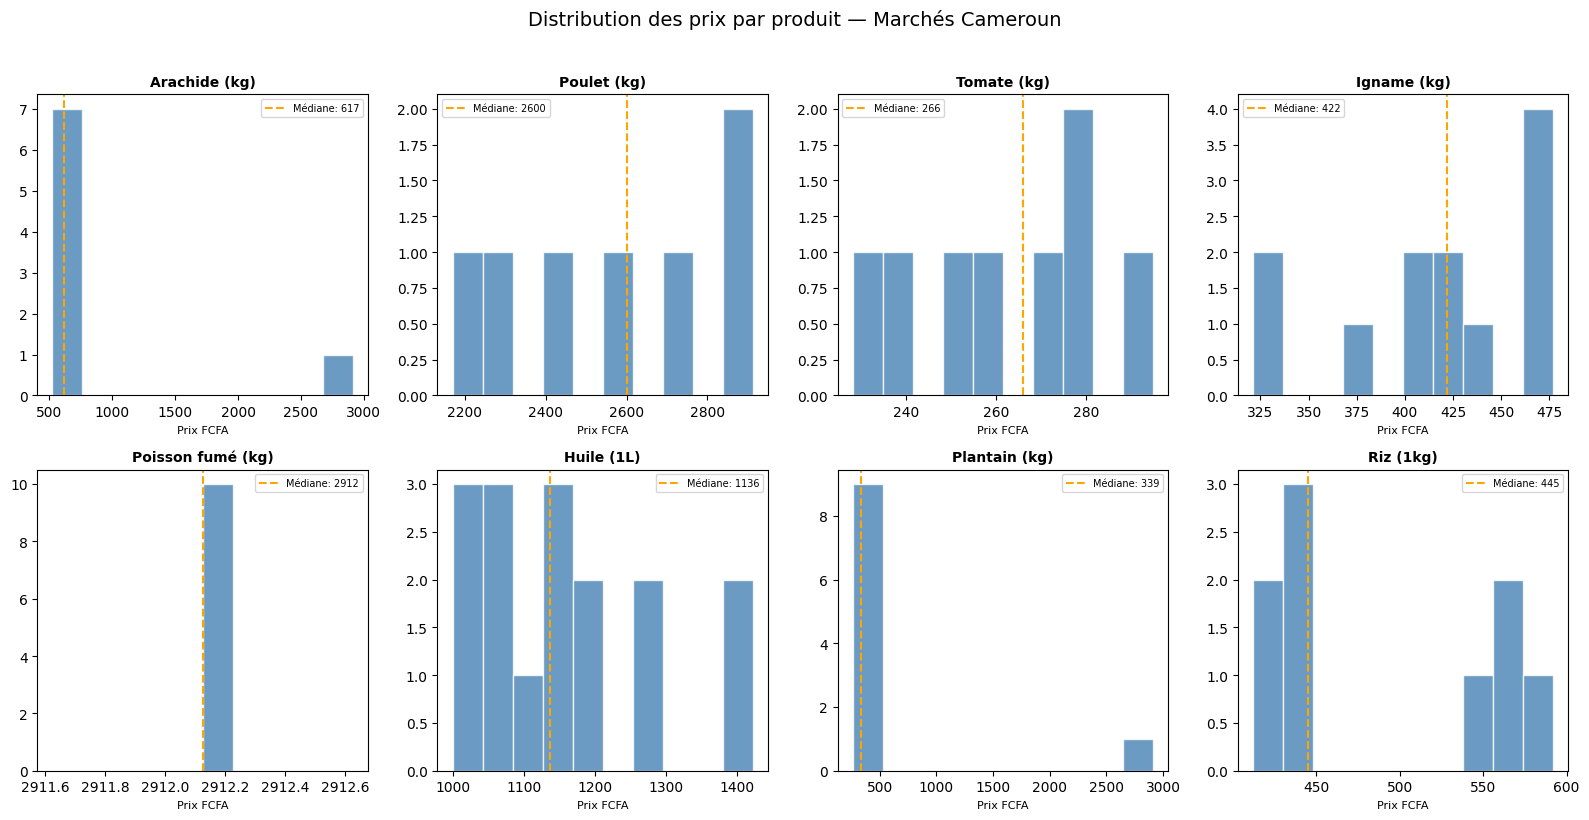

In [29]:
import matplotlib.pyplot as plt

# Configuration de la figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
produits_liste = df['produit'].unique()

# Boucle de génération des histogrammes
for i, prod in enumerate(produits_liste):
    ax = axes[i//4, i%4]
    data_prod = df[df['produit'] == prod]['prix_fcfa']
    
    # Histogramme
    ax.hist(data_prod, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    
    # Ligne de la médiane
    ax.axvline(data_prod.median(), color='orange', linestyle='--', label=f'Médiane: {data_prod.median():.0f}')
    
    # Formatage
    ax.set_title(prod, fontsize=10, fontweight='bold')
    ax.set_xlabel('Prix FCFA', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Distribution des prix par produit — Marchés Cameroun', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


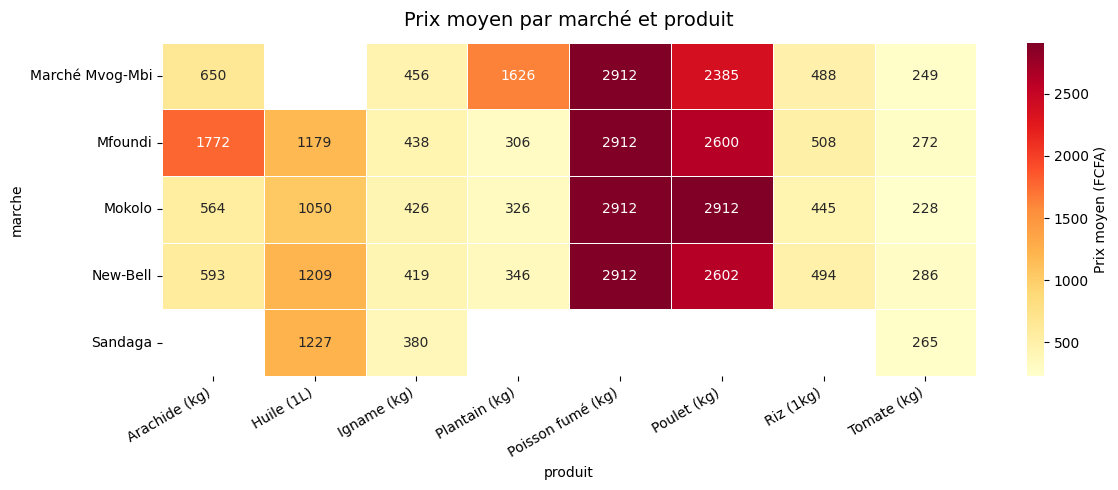

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Préparation des données pour la heatmap
pivot_viz = df.pivot_table(
    values='prix_fcfa', 
    index='marche', 
    columns='produit', 
    aggfunc='mean'
)

# Configuration de la visualisation
plt.figure(figsize=(12, 5))
sns.heatmap(
    pivot_viz, 
    annot=True,     # Affiche les valeurs numériques dans les cases
    fmt='.0f',       # Format sans décimales
    cmap='YlOrRd',  # Dégradé de jaune à rouge
    linewidths=0.5, 
    cbar_kws={'label': 'Prix moyen (FCFA)'}
)

plt.title('Prix moyen par marché et produit', fontsize=14, pad=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


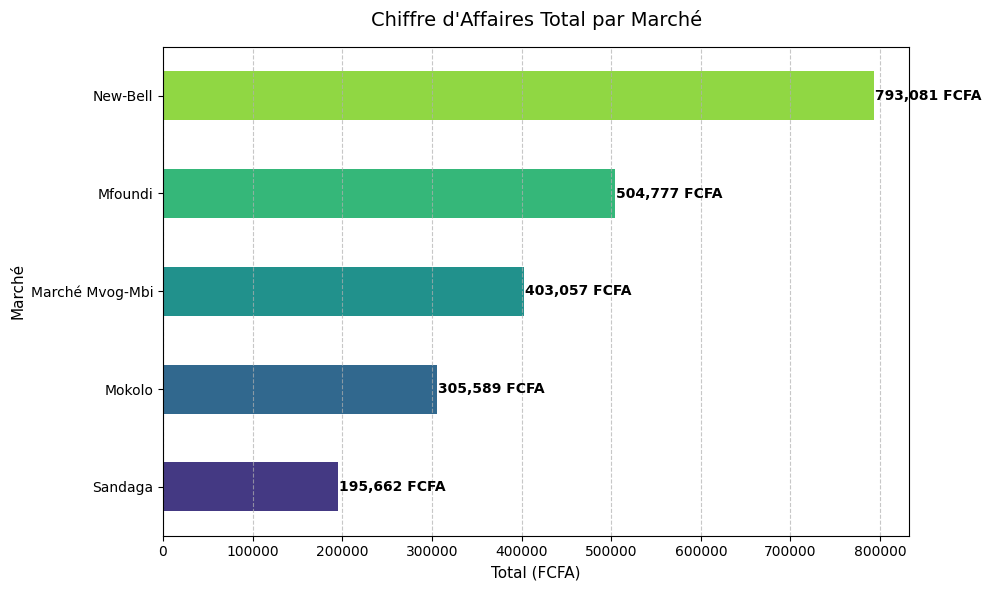

In [31]:
plt.figure(figsize=(10, 6))
ca_par_marche = df.groupby('marche')['total'].sum().sort_values()

# Création du graphique
colors = sns.color_palette('viridis', len(ca_par_marche))
ca_par_marche.plot(kind='barh', color=colors)

# Ajout des étiquettes de données
for i, v in enumerate(ca_par_marche):
    plt.text(v + 1000, i, f'{int(v):,} FCFA', va='center', fontsize=10, fontweight='bold')

plt.title('Chiffre d\'Affaires Total par Marché', fontsize=14, pad=15)
plt.xlabel('Total (FCFA)', fontsize=11)
plt.ylabel('Marché', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [33]:
# Étape 6.1 — Sauvegarder le dataset nettoyé

# 1. Export en CSV (Format universel, léger)
df.to_csv('marches_cameroun_propre.csv', index=False, encoding='utf-8')

# 2. Export en Excel avec plusieurs feuilles (Format professionnel)
with pd.ExcelWriter('marches_cameroun_propre.xlsx', engine='openpyxl') as writer:
    # Feuille principale avec toutes les données nettoyées
    df.to_excel(writer, sheet_name='Données_nettoyées', index=False)
    
    # Feuille de synthèse : Statistiques par produit
    stats_resume = df.groupby('produit').agg(
        prix_moyen=('prix_fcfa', 'mean'),
        prix_median=('prix_fcfa', 'median'),
        qty_totale=('quantite', 'sum'),
        ca_total=('total', 'sum')
    ).round(0).reset_index()
    
    stats_resume.to_excel(writer, sheet_name='Statistiques', index=False)

print(' Fichiers exportés avec succès !')
print(f" Résumé : {df.shape[0]} lignes prêtes pour le reporting.")


 Fichiers exportés avec succès !
 Résumé : 80 lignes prêtes pour le reporting.
